# Walk-Forward Validation

This notebook evaluates the temporal robustness and generalization performance of the final Reduced XGBoost model using expanding-window walk-forward validation.

## Load Data and Model Artifacts

The engineered dataset and the final selected feature set are loaded to reproduce the Reduced XGBoost forecasting pipeline. This ensures that walk-forward validation is performed using the same feature space as the final deployed model.

In [12]:
import pandas as pd
import numpy as np
import joblib

from xgboost import XGBRegressor

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [13]:
# Load dataset

df = pd.read_csv("../data/processed/model_ready_features.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (50232, 31)


In [14]:
# Load selected features

selected_features = joblib.load(
    "../models/selected_features.pkl"
)

print("Selected features loaded successfully.")
print(f"Number of features: {len(selected_features)}")

Selected features loaded successfully.
Number of features: 21


In [15]:
selected_features

['DE_solar_generation_actual',
 'DE_wind_generation_actual',
 'temperature_C',
 'wind_speed_ms',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'quarter',
 'week_of_year',
 'renewable_share_pct',
 'load_lag_1',
 'load_lag_24',
 'load_lag_168',
 'rolling_mean_24',
 'hour_sin',
 'hour_cos',
 'season_Spring',
 'season_Summer',
 'season_Winter']

In [16]:
# Convert timestamp to datetime

df["utc_timestamp"] = pd.to_datetime(
    df["utc_timestamp"]
)

df["year_actual"] = df["utc_timestamp"].dt.year

df[["utc_timestamp", "year_actual"]].head()

,utc_timestamp,year_actual
0,2015-01-08 00:00:00+00:00,2015
1,2015-01-08 01:00:00+00:00,2015
2,2015-01-08 02:00:00+00:00,2015
3,2015-01-08 03:00:00+00:00,2015
4,2015-01-08 04:00:00+00:00,2015


### Dataset Preparation

The timestamp column was converted to a datetime format to enable temporal splitting of the dataset. An additional year variable was extracted to facilitate the creation of chronological walk-forward validation folds.

This approach ensures that training data always precedes testing data in time, thereby preventing information leakage and simulating real-world forecasting conditions.

In [17]:
df["year_actual"].value_counts().sort_index()

year_actual
2015    8592
2016    8784
2017    8760
2018    8760
2019    8760
2020    6576
Name: count, dtype: int64

## Create Walk-Forward Validation Folds

An expanding-window walk-forward validation strategy was adopted to evaluate model robustness over time.

For each fold, the model was trained using all available historical observations up to a given year and then evaluated on the subsequent unseen year. This procedure mimics real-world deployment conditions, where future observations are unavailable during model training.

Three validation folds were constructed:

- Fold 1: Train (2015–2017), Test (2018)
- Fold 2: Train (2015–2018), Test (2019)
- Fold 3: Train (2015–2019), Test (2020)

In [18]:
target = "DE_load_actual_entsoe_transparency"

walk_forward_folds = [
    {
        "name": "Fold 1",
        "train_end": 2017,
        "test_year": 2018
    },
    {
        "name": "Fold 2",
        "train_end": 2018,
        "test_year": 2019
    },
    {
        "name": "Fold 3",
        "train_end": 2019,
        "test_year": 2020
    }
]

walk_forward_folds

[{'name': 'Fold 1', 'train_end': 2017, 'test_year': 2018},
 {'name': 'Fold 2', 'train_end': 2018, 'test_year': 2019},
 {'name': 'Fold 3', 'train_end': 2019, 'test_year': 2020}]

In [19]:
for fold in walk_forward_folds:

    train_df = df[
        df["year_actual"] <= fold["train_end"]
    ]

    test_df = df[
        df["year_actual"] == fold["test_year"]
    ]

    print(f"{fold['name']}")
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape : {test_df.shape}")
    print("-" * 40)

Fold 1
Train shape: (26136, 32)
Test shape : (8760, 32)
----------------------------------------
Fold 2
Train shape: (34896, 32)
Test shape : (8760, 32)
----------------------------------------
Fold 3
Train shape: (43656, 32)
Test shape : (6576, 32)
----------------------------------------


### Walk-Forward Fold Verification

The fold sizes increase progressively as additional historical information becomes available to the model. This expanding-window strategy reflects how forecasting systems are typically retrained in operational environments, where historical data accumulates over time.

The approach provides a stronger assessment of model generalization compared with a single train-test split because performance is evaluated across multiple future periods.

## Train and Evaluate the Reduced XGBoost Model

For each walk-forward fold, the Reduced XGBoost model is retrained using only historical data available up to the training period and then evaluated on the subsequent unseen year.

The following performance metrics are recorded:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

This process assesses the model's ability to generalize across multiple future periods rather than relying on a single train-test split.

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

results = []

In [21]:
for fold in walk_forward_folds:

    print(f"\nRunning {fold['name']}...")
    
    train_df = df[
        df["year_actual"] <= fold["train_end"]
    ]

    test_df = df[
        df["year_actual"] == fold["test_year"]
    ]

    X_train = train_df[selected_features]
    y_train = train_df[target]

    X_test = test_df[selected_features]
    y_test = test_df[target]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Fold": fold["name"],
        "Train_End_Year": fold["train_end"],
        "Test_Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")


Running Fold 1...
MAE : 482.80
RMSE: 673.14
R²  : 0.9953

Running Fold 2...
MAE : 451.05
RMSE: 594.30
R²  : 0.9964

Running Fold 3...
MAE : 507.17
RMSE: 676.09
R²  : 0.9952


### Walk-Forward Validation Results

The Reduced XGBoost model demonstrated strong and consistent performance across all walk-forward validation folds. The model achieved R² scores above 0.995 in each test year, indicating excellent generalization to unseen future periods.

Performance was strongest in 2019, with an MAE of 451.05 MW and an RMSE of 594.30 MW. The 2020 fold showed slightly higher error, which may reflect changes in demand behavior during that period, but performance remained highly accurate overall.

These results provide stronger evidence of model robustness than a single chronological train-test split, confirming that the forecasting model can maintain high predictive accuracy across multiple future evaluation periods.

In [22]:
walk_forward_results = pd.DataFrame(results)

walk_forward_results

,Fold,Train_End_Year,Test_Year,MAE,RMSE,R2
0,Fold 1,2017,2018,482.802598,673.141759,0.995348
1,Fold 2,2018,2019,451.048468,594.295597,0.996391
2,Fold 3,2019,2020,507.173598,676.087285,0.995176


In [23]:
walk_forward_summary = walk_forward_results[
    ['MAE', 'RMSE', 'R2']
].agg(['mean', 'std'])

walk_forward_summary

,MAE,RMSE,R2
mean,480.341555,647.841547,0.995638
std,28.143385,46.395534,0.000657


### Walk-Forward Validation Summary

The walk-forward validation results demonstrate that the Reduced XGBoost model maintains highly consistent forecasting performance across multiple future evaluation periods.

Across all validation folds, the model achieved an average MAE of 480.34 MW, an average RMSE of 647.84 MW, and an average R² score of 0.9956. The small standard deviations observed for all metrics indicate strong temporal stability and suggest that the model generalizes well beyond a single train-test split.

The consistently high R² values across 2018, 2019, and 2020 provide strong evidence that the forecasting model captures persistent demand patterns and is robust to variations in future electricity consumption behavior.

These findings significantly strengthen confidence in the suitability of the Reduced XGBoost model for real-world electricity demand forecasting applications.

## Walk-Forward Validation Performance by Fold

The forecasting performance of the Reduced XGBoost model was visualized across all walk-forward validation folds to assess temporal consistency and identify any potential degradation in predictive accuracy over time.

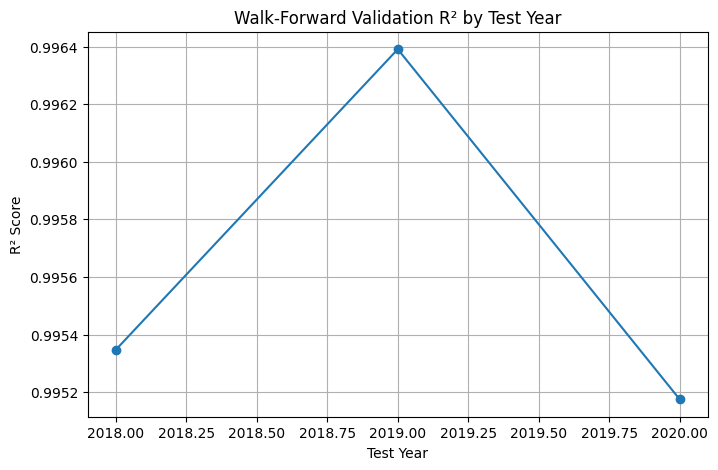

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    walk_forward_results['Test_Year'],
    walk_forward_results['R2'],
    marker='o'
)

plt.title('Walk-Forward Validation R² by Test Year')
plt.xlabel('Test Year')
plt.ylabel('R² Score')

plt.grid(True)

plt.show()

# Conclusions

This notebook evaluated the temporal robustness and generalization performance of the final Reduced XGBoost forecasting model using an expanding-window walk-forward validation framework.

The model achieved consistently strong performance across all validation folds, recording R² scores above 0.995 for the 2018, 2019, and 2020 test periods. The low variability observed in MAE, RMSE, and R² metrics across folds indicates that the model maintains stable predictive performance when applied to unseen future data.

The walk-forward validation results complement previous analyses conducted during model development, including chronological train-test evaluation, feature importance analysis, SHAP explainability, feature ablation studies, and feature selection experiments. Together, these robustness assessments provide strong evidence that the Reduced XGBoost model captures persistent electricity demand patterns rather than memorizing specific historical observations.

Overall, the forecasting framework demonstrated high predictive accuracy, strong temporal stability, and excellent generalization capability. These findings support the suitability of the Reduced XGBoost model for practical short-term electricity demand forecasting applications and establish a reliable foundation for subsequent energy system analyses within this project.


## Next Steps

Having established a robust and generalizable demand forecasting framework, the next phase of the project will focus on solar generation prediction and the integration of forecasting outputs into carbon impact and energy transition analyses.